<a href="https://colab.research.google.com/github/Clydeew/5-AhmadDzaki/blob/main/UK_House_Prices_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA LOADING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path  = '/content/drive/MyDrive/Internship BCC/df_merged.csv'
# path = '/content/drive/MyDrive/Internship BCC/Project/df_merged.csv'
df = pd.read_csv(path)
display(df)

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,district_clean,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type
0,280000,2022-06-06,B78 3XA,D,N,F,WESTMORLAND CLOSE,TAMWORTH,TAMWORTH,STAFFORDSHIRE,A,2022,TAMWORTH,31,81117,2630,Urban
1,312500,2022-06-20,ST7 4JZ,D,N,F,SANDS ROAD,STOKE-ON-TRENT,NEWCASTLE-UNDER-LYME,STAFFORDSHIRE,A,2022,NEWCASTLEUNDERLYME,211,127727,605,Urban
2,150000,2022-06-30,ST14 7QG,S,N,F,LAMBERT ROAD,UTTOXETER,EAST STAFFORDSHIRE,STAFFORDSHIRE,A,2022,EAST STAFFFORDSHIRE,387,129659,335,Urban
3,515000,2022-05-25,B78 3UG,D,N,F,MOAT DRIVE,TAMWORTH,LICHFIELD,STAFFORDSHIRE,A,2022,LICHFIELD,331,111932,338,Urban
4,262500,2022-07-15,ST20 0HY,D,N,F,HOLLIES BROOK CLOSE,STAFFORD,STAFFORD,STAFFORDSHIRE,A,2022,STAFFFORD,598,141556,237,Rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,WOKINGHAM,179,187200,1046,Urban
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,WEST BERKSHIRE,704,165112,234,Rural
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,WINDSOR AND MAIDENHEAD,196,158943,809,Urban
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,BRACKNELL FOREST,109,130806,1196,Urban


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3629280 entries, 0 to 3629279
Data columns (total 17 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   price                          int64 
 1   date_of_transfer               object
 2   postcode                       object
 3   property_type                  object
 4   old_new                        object
 5   duration                       object
 6   street                         object
 7   town_city                      object
 8   district                       object
 9   county                         object
 10  ppd_category_type              object
 11  year                           int64 
 12  district_clean                 object
 13  Area (sq km)                   int64 
 14  Estimated Population mid-2024  int64 
 15  2024 people per sq. km         int64 
 16  area_type                      object
dtypes: int64(5), object(12)
memory usage: 470.7+ MB


In [ ]:
df.isna().sum()

,0
price,0
date_of_transfer,0
postcode,9244
property_type,0
old_new,0
duration,0
street,58898
town_city,0
district,0
county,0


# PREPROCESSING

## OUTLIER HANDLING

In [ ]:
df = df[df['ppd_category_type'] == 'A']

In [ ]:
display(df['price'].describe())

upper = df['price'].quantile(0.995)
lower = df['price'].quantile(0.001)

,price
count,3.042101e+06
mean,3.676222e+05
std,4.123564e+05
min,1.000000e+00
25%,1.930000e+05
50%,2.900000e+05
75%,4.300000e+05
max,1.345000e+08


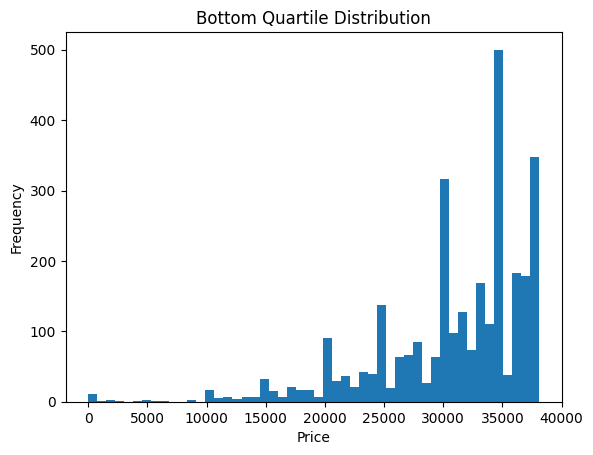

In [ ]:
plt.figure()
plt.hist(df['price'][df['price'] <= lower], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Bottom Quartile Distribution')
plt.show()

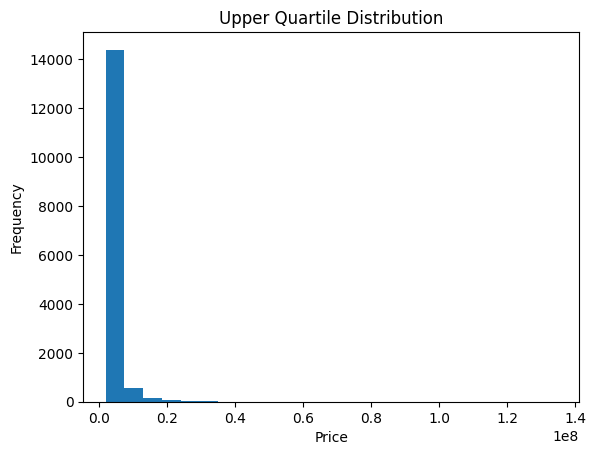

In [ ]:
plt.figure()
plt.hist(df['price'][df['price'] >= upper], bins=24)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Upper Quartile Distribution')
plt.show()

In [ ]:
df = df[df['price'] >= 10000]

In [ ]:
df = df[df['price']<=upper]

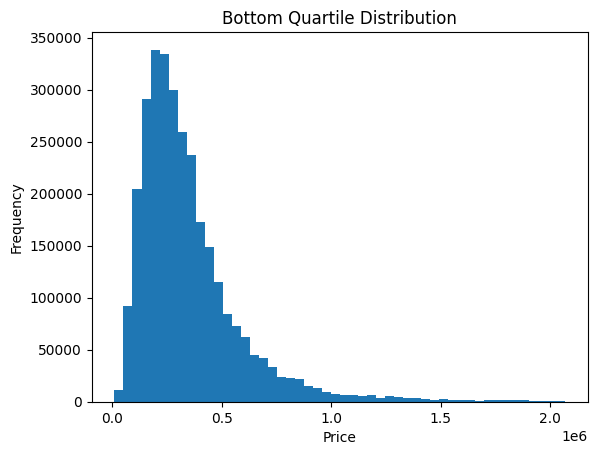

In [ ]:
plt.figure()
plt.hist(df['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Bottom Quartile Distribution')
plt.show()

In [ ]:
df['price'].max()

2070000

## DATA SAMPLING

In [ ]:
df_sampled = df[
    (df['date_of_transfer'] >= '2025-06-01') &
    (df['date_of_transfer'] <= '2026-1-31')
]
df_sampled

,price,date_of_transfer,postcode,property_type,old_new,duration,street,town_city,district,county,ppd_category_type,year,district_clean,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type
2856020,795000,2025-10-24,SK10 5XF,D,N,F,CHAPEL BROW,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,A,2025,CHESHIRE EAST,1166,421298,361,Urban
2856021,141000,2025-11-21,SK11 7AF,T,N,F,JODRELL STREET,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,A,2025,CHESHIRE EAST,1166,421298,361,Urban
2856022,184000,2025-11-27,CH4 7NP,T,N,F,BARONY WAY,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,2025,CHESHIRE WEST AND CHESTER,920,371652,404,Urban
2856023,263000,2025-06-20,WA8 7NN,S,N,F,LYNTON CRESCENT,WIDNES,HALTON,HALTON,A,2025,HALTON,79,131543,1663,Urban
2856024,630000,2025-07-09,CH3 5QB,D,N,F,WHITCHURCH ROAD,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,2025,CHESHIRE WEST AND CHESTER,920,371652,404,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629275,875000,2026-01-15,RG41 4XJ,D,N,F,JAPONICA CLOSE,WOKINGHAM,WOKINGHAM,WOKINGHAM,A,2026,WOKINGHAM,179,187200,1046,Urban
3629276,370000,2026-01-14,RG20 6QQ,T,N,F,MEADOW CLOSE,NEWBURY,WEST BERKSHIRE,WEST BERKSHIRE,A,2026,WEST BERKSHIRE,704,165112,234,Rural
3629277,700000,2026-01-15,SL3 9NQ,S,N,F,FAIRFIELD AVENUE,SLOUGH,WINDSOR AND MAIDENHEAD,WINDSOR AND MAIDENHEAD,A,2026,WINDSOR AND MAIDENHEAD,196,158943,809,Urban
3629278,283000,2026-01-16,GU47 0ZB,T,N,F,STUBBS FOLLY,SANDHURST,BRACKNELL FOREST,BRACKNELL FOREST,A,2026,BRACKNELL FOREST,109,130806,1196,Urban


## DISTRIBUTION CHECKING

In [ ]:
df_district = df_sampled['district'].value_counts()
display(df_district)

df_district.describe()

,count
district,
NORTH YORKSHIRE,4969
LEEDS,4922
SOMERSET,4293
BIRMINGHAM,4278
CORNWALL,4115
...,...
RUTLAND,312
OADBY AND WIGSTON,290
MERTHYR TYDFIL,261


,count
count,318.000000
mean,1143.474843
std,742.109168
min,5.000000
25%,717.250000
50%,948.500000
75%,1292.000000
max,4969.000000


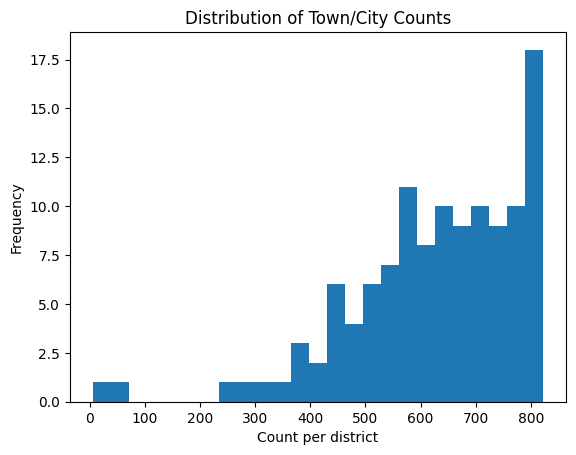

In [ ]:
plt.figure()
plt.hist(df_district[df_district < 826], bins=25)
plt.xlabel('Count per district')
plt.ylabel('Frequency')
plt.title('Distribution of Town/City Counts')
plt.show()

In [ ]:
df_tc = df_sampled['town_city'].value_counts()
display(df_tc)
df_tc.describe()

,count
town_city,
LONDON,20411
BRISTOL,6045
MANCHESTER,5617
NOTTINGHAM,4891
BIRMINGHAM,4332
...,...
MONTACUTE,2
MINDRUM,1
DULAS,1


,count
count,1144.000000
mean,317.854021
std,782.597679
min,1.000000
25%,59.750000
50%,152.000000
75%,319.250000
max,20411.000000


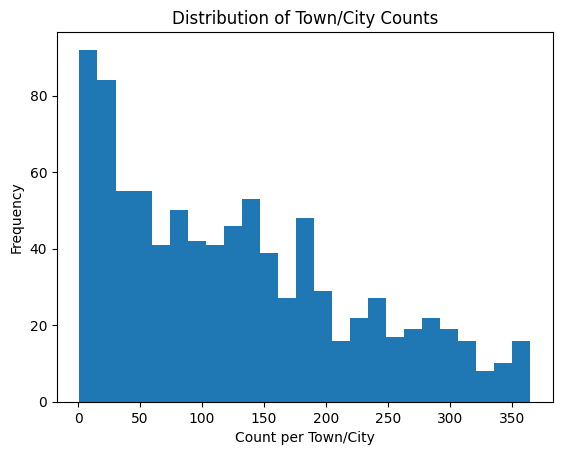

In [ ]:
plt.figure()
plt.hist(df_tc[df_tc < 367], bins=25)
plt.xlabel('Count per Town/City')
plt.ylabel('Frequency')
plt.title('Distribution of Town/City Counts')
plt.show()

In [ ]:
df_county = df_sampled['county'].value_counts()
display(df_county)
df_county.describe()

,count
county,
GREATER LONDON,35028
GREATER MANCHESTER,15986
WEST YORKSHIRE,14837
WEST MIDLANDS,12275
KENT,10682
...,...
ISLE OF ANGLESEY,391
BLAENAU GWENT,364
RUTLAND,312


,count
count,113.000000
mean,3217.920354
std,4307.866805
min,5.000000
25%,1021.000000
50%,1416.000000
75%,4152.000000
max,35028.000000


In [ ]:
df_sampled['county'].replace('ISLES OF SCILLY', 'CORNWALL', inplace=True)
df_county = df_sampled['county'].value_counts()
display(df_county)
df_county.describe()

,count
county,
GREATER LONDON,35028
GREATER MANCHESTER,15986
WEST YORKSHIRE,14837
WEST MIDLANDS,12275
KENT,10682
...,...
SLOUGH,423
ISLE OF ANGLESEY,391
BLAENAU GWENT,364


,count
count,112.000000
mean,3246.651786
std,4316.381870
min,261.000000
25%,1021.750000
50%,1438.000000
75%,4187.250000
max,35028.000000


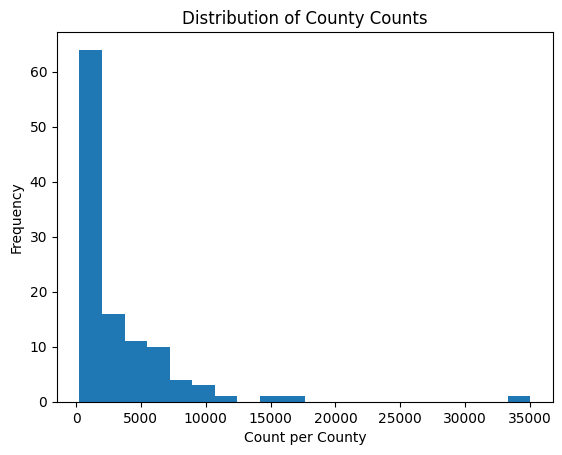

In [ ]:
plt.figure()
plt.hist(df_county, bins=20)
plt.xlabel('Count per County')
plt.ylabel('Frequency')
plt.title('Distribution of County Counts')
plt.show()

In [ ]:
df_sampled['old_new'].value_counts()

,count
old_new,
N,360279
Y,3346


In [ ]:
df_sampled['duration'].value_counts()

,count
duration,
F,289979
L,73646


In [ ]:
df_sampled['property_type'].value_counts()

,count
property_type,
S,109964
T,105986
D,90441
F,57234


In [ ]:
df.isna().sum()

,0
price,0
date_of_transfer,0
postcode,524
property_type,0
old_new,0
duration,0
street,41569
town_city,0
district,0
county,0


In [ ]:
df_price = df_sampled['price']

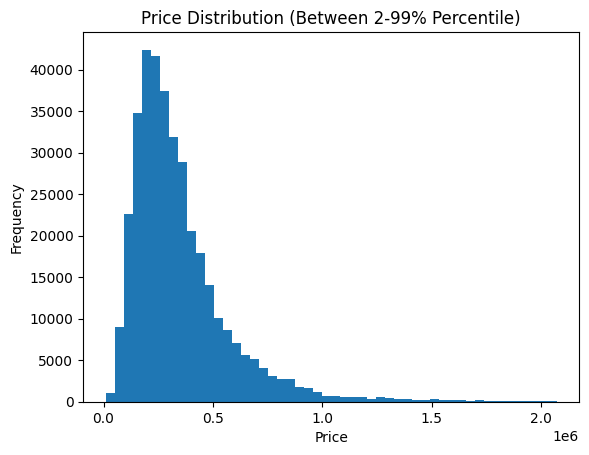

In [ ]:

plt.figure()
plt.hist(df_price, bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution (Between 2-99% Percentile)')
plt.show()

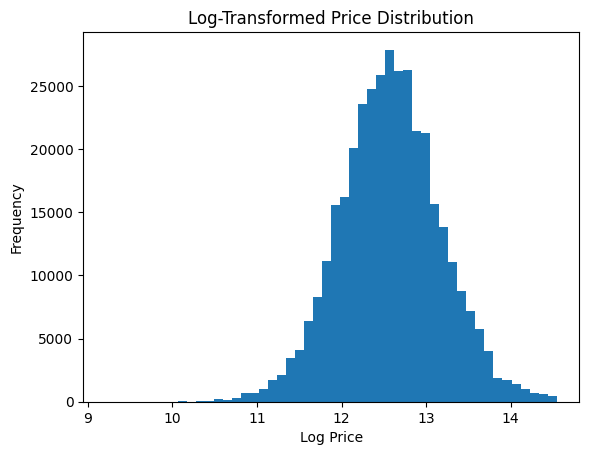

In [ ]:
plt.figure()
plt.hist(np.log1p(df_price), bins=50)
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.title('Log-Transformed Price Distribution')
plt.show()

In [ ]:
df_price.describe()

,price
count,3.636250e+05
mean,3.476698e+05
std,2.318235e+05
min,1.000000e+04
25%,1.957000e+05
50%,2.900000e+05
75%,4.250000e+05
max,2.070000e+06


In [ ]:
df_price.min()

10000

## SPLITTING

In [ ]:
train_mask = (df["date_of_transfer"] >= "2025-06-01") & (df["date_of_transfer"] <= "2025-11-30")
# valid_mask = (df["date_of_transfer"] >= "2025-12-01") & (df["date_of_transfer"] <= "2025-12-31")
test_mask  = (df["date_of_transfer"] >= "2025-12-01") & (df["date_of_transfer"] <= "2026-01-31")

train_df = df[train_mask].copy()
# valid_df = df[valid_mask].copy()
test_df  = df[test_mask].copy()

In [ ]:
total_data = len(df_sampled)

print(f'{len(train_df)} ({len(train_df)/total_data*100} %)')
# print(f'{len(valid_df)} ({len(valid_df)/total_data*100} %)')
print(f'{len(test_df)} ({len(test_df)/total_data*100} %)')

305785 (84.09350292196632 %)
57840 (15.906497078033688 %)


## CLEANING

In [ ]:
train_df.columns

Index(['price', 'date_of_transfer', 'postcode', 'property_type', 'old_new',
       'duration', 'street', 'town_city', 'district', 'county',
       'ppd_category_type', 'year', 'district_clean', 'Area (sq km)',
       'Estimated Population mid-2024', '2024 people per sq. km', 'area_type'],
      dtype='object')

In [ ]:
display(train_df.isna().sum())
display(test_df.isna().sum())

,0
price,0
date_of_transfer,0
postcode,84
property_type,0
old_new,0
duration,0
street,4109
town_city,0
district,0
county,0


,0
price,0
date_of_transfer,0
postcode,19
property_type,0
old_new,0
duration,0
street,846
town_city,0
district,0
county,0


In [ ]:
def clean_df(d):
    d = d.copy()
    d["date_of_transfer"] = pd.to_datetime(d["date_of_transfer"])
    d = d.drop(columns=["postcode", "street", "ppd_category_type", "district_clean"]) #Postcode and Street remove due to too many missing value and too high cardinality, ppd_category_type is due to only one type is in this dataset
    d["month"] = d["date_of_transfer"].dt.month
    d = d.drop(columns=["date_of_transfer", "year"])

    return d

train_df = clean_df(train_df)
# valid_df = clean_df(valid_df)
test_df  = clean_df(test_df)

In [ ]:
print(train_df.isna().sum().sum())
print(train_df.isna().sum().sum())
print(train_df.isna().sum().sum())

0
0
0


In [ ]:
train_df.head()

,price,property_type,old_new,duration,town_city,district,county,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type,month
2856020,795000,D,N,F,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,1166,421298,361,Urban,10
2856021,141000,T,N,F,MACCLESFIELD,CHESHIRE EAST,CHESHIRE EAST,1166,421298,361,Urban,11
2856022,184000,T,N,F,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,920,371652,404,Urban,11
2856023,263000,S,N,F,WIDNES,HALTON,HALTON,79,131543,1663,Urban,6
2856024,630000,D,N,F,CHESTER,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,920,371652,404,Urban,7


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 305785 entries, 2856020 to 3613272
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   price                          305785 non-null  int64 
 1   property_type                  305785 non-null  object
 2   old_new                        305785 non-null  object
 3   duration                       305785 non-null  object
 4   town_city                      305785 non-null  object
 5   district                       305785 non-null  object
 6   county                         305785 non-null  object
 7   Area (sq km)                   305785 non-null  int64 
 8   Estimated Population mid-2024  305785 non-null  int64 
 9   2024 people per sq. km         305785 non-null  int64 
 10  area_type                      305785 non-null  object
 11  month                          305785 non-null  int32 
dtypes: int32(1), int64(4), object(7)
memory us

In [ ]:
target = "price"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

# X_valid = valid_df.drop(columns=[target])
# y_valid = valid_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [ ]:
display(y_train)
display(y_test)

,price
2856020,795000
2856021,141000
2856022,184000
2856023,263000
2856024,630000
...,...
3613263,332500
3613267,367500
3613270,395000
3613271,125000


,price
2856026,305000
2856029,242000
2856031,927500
2856033,194000
2856035,232500
...,...
3629275,875000
3629276,370000
3629277,700000
3629278,283000


### LOG TRANSFORM

In [ ]:
# Apply log transform only to the training set
y_train_log = np.log1p(y_train)
# y_test_log  = np.log1p(y_test)

## ENCODING

### LOW CARDINALITY COLUMN ENCODING

In [ ]:
binary_cols = ["old_new", "duration", "area_type"]

maps = {
    "old_new": {"N": 0, "Y": 1},
    "duration": {"L": 0, "F": 1},
    "area_type": {"Urban": 1, "Rural": 0}

}

for col in binary_cols:
    X_train[col] = X_train[col].map(maps[col])
    # X_valid[col] = X_valid[col].map(maps[col])
    X_test[col]  = X_test[col].map(maps[col])

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[['property_type']])
# X_valid_ohe = ohe.transform(X_valid[['property_type']])
X_test_ohe  = ohe.transform(X_test[['property_type']])

In [ ]:
ohe_cols = ohe.get_feature_names_out(['property_type']).tolist()

ohe_train_df = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
# ohe_valid_df = pd.DataFrame(X_valid_ohe, columns=ohe_cols, index=X_valid.index)
ohe_test_df  = pd.DataFrame(X_test_ohe,  columns=ohe_cols, index=X_test.index)


In [ ]:
ohe_train_df

,property_type_D,property_type_F,property_type_S,property_type_T
2856020,1.0,0.0,0.0,0.0
2856021,0.0,0.0,0.0,1.0
2856022,0.0,0.0,0.0,1.0
2856023,0.0,0.0,1.0,0.0
2856024,1.0,0.0,0.0,0.0
...,...,...,...,...
3613263,1.0,0.0,0.0,0.0
3613267,0.0,0.0,1.0,0.0
3613270,0.0,0.0,1.0,0.0
3613271,0.0,1.0,0.0,0.0


In [ ]:
X_train = pd.concat([X_train.drop(columns=['property_type']), ohe_train_df], axis=1)
# X_valid = pd.concat([X_valid.drop(columns=['property_type']), ohe_valid_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=['property_type']),  ohe_test_df],  axis=1)

### HIGH CARDINALITY ENCODING

In [ ]:
train_df["price_log"] = np.log1p(train_df["price"]) # Using train_df to prevent data leaking

#Global Median
global_median = train_df["price_log"].median()

#For County Encoding
county_map = train_df.groupby("county")["price_log"].median()
#For District Encoding
district_counts = train_df["district"].value_counts()
#Threshold
MIN_DISTRICT = 80

valid_districts = district_counts[district_counts >= MIN_DISTRICT].index

district_map = train_df[train_df["district"].isin(valid_districts)] \
    .groupby("district")["price_log"].median()

# For Town_City Encoding
tc_counts = train_df["town_city"].value_counts()
# Threshold
MIN_TC = 60

valid_towns = tc_counts[tc_counts >= MIN_TC].index

town_map = train_df[train_df["town_city"].isin(valid_towns)] \
    .groupby("town_city")["price_log"].median()

def encode_location(df):
    town_enc = df["town_city"].map(town_map)
    district_enc = df["district"].map(district_map)
    county_enc = df["county"].map(county_map)

    # hierarchy
    return (
        town_enc
        .fillna(district_enc)
        .fillna(county_enc)
        .fillna(global_median)
    )
# apply
X_train["location_enc"] = encode_location(X_train)
# X_valid["location_enc"] = encode_location(X_valid)
X_test["location_enc"]  = encode_location(X_test)

# drop originals
X_train = X_train.drop(columns=["town_city", "district", "county"])
# X_valid = X_valid.drop(columns=["town_city", "district", "county"])
X_test  = X_test.drop(columns=["town_city", "district", "county"])

### CYCLICAL ENCODING

In [ ]:
for df in [X_train,
          #  X_valid,
           X_test]:
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# drop original
X_train = X_train.drop(columns=["month"])
# X_valid = X_valid.drop(columns=["month"])
X_test  = X_test.drop(columns=["month"])

In [ ]:
X_train

,old_new,duration,Area (sq km),Estimated Population mid-2024,2024 people per sq. km,area_type,property_type_D,property_type_F,property_type_S,property_type_T,location_enc,month_sin,month_cos
2856020,NaN,NaN,1166,421298,361,NaN,1.0,0.0,0.0,0.0,12.594734,-8.660254e-01,5.000000e-01
2856021,NaN,NaN,1166,421298,361,NaN,0.0,0.0,0.0,1.0,12.594734,-5.000000e-01,8.660254e-01
2856022,NaN,NaN,920,371652,404,NaN,0.0,0.0,0.0,1.0,12.510789,-5.000000e-01,8.660254e-01
2856023,NaN,NaN,79,131543,1663,NaN,0.0,0.0,1.0,0.0,12.154785,1.224647e-16,-1.000000e+00
2856024,NaN,NaN,920,371652,404,NaN,1.0,0.0,0.0,0.0,12.510789,-5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3613263,NaN,NaN,663,138017,208,NaN,1.0,0.0,0.0,0.0,12.611541,-1.000000e+00,-1.836970e-16
3613267,NaN,NaN,33,106671,3199,NaN,0.0,0.0,1.0,0.0,12.524530,-8.660254e-01,-5.000000e-01
3613270,NaN,NaN,54,87847,1619,NaN,0.0,0.0,1.0,0.0,12.449023,-5.000000e-01,-8.660254e-01
3613271,NaN,NaN,33,106671,3199,NaN,0.0,1.0,0.0,0.0,12.524530,-5.000000e-01,8.660254e-01


In [ ]:
print(X_train)

In [ ]:
y_test

,price
2856026,305000
2856029,242000
2856031,927500
2856033,194000
2856035,232500
...,...
3629275,875000
3629276,370000
3629277,700000
3629278,283000


In [ ]:
display(y_train.describe())
# display(y_valid.describe())
display(y_test.describe())

,price
count,3.057850e+05
mean,3.489193e+05
std,2.348531e+05
min,1.000000e+04
25%,1.950000e+05
50%,2.900000e+05
75%,4.250000e+05
max,2.070000e+06


,price
count,5.784000e+04
mean,3.410641e+05
std,2.149805e+05
min,1.500000e+04
25%,1.980000e+05
50%,2.900000e+05
75%,4.220000e+05
max,2.060000e+06


## FEATURE ENGINEERING

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

# Feature importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))

location_enc                     0.536114
property_type_D                  0.210775
property_type_F                  0.075813
Area (sq km)                     0.057550
Estimated Population mid-2024    0.031735
2024 people per sq. km           0.028292
month_cos                        0.026832
month_sin                        0.016779
property_type_S                  0.010761
property_type_T                  0.005350
old_new                          0.000000
duration                         0.000000
area_type                        0.000000
dtype: float64


In [ ]:
features_to_drop = ['area_type', 'duration', 'old_new']

X_train = X_train.drop(columns=features_to_drop)
# X_valid = X_valid.drop(columns=features_to_drop)
X_test  = X_test.drop(columns=features_to_drop)

# MODELING

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

## Baseline Hyperparameter

In [ ]:
# Linear Regression Model
lr = LinearRegression()

# Random Forest Model
rf = RandomForestRegressor(
    random_state=42
)

# XGBoost Model
xgb = XGBRegressor(
    random_state=42
)

# LightGBM Model
lgbm = LGBMRegressor(
    random_state=42
)

# Gradient Boosting Model
gb = GradientBoostingRegressor(
    random_state=42
)

# Adaptive Boosting Model
ab = AdaBoostRegressor(
    random_state=42
)

# K-Nearest Neighbors Model
knn = KNeighborsRegressor(

)

# Support Vector Machine Model
svm = SVR(

)

## Performance Evaluation (Pre-Tuning)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)

In [ ]:
# def rmsle(y_true, y_pred):
#     return np.sqrt(mean_squared_log_error(y_true, y_pred))

# rmsle_scorer = make_scorer(rmsle, greater_is_better=False)


In [ ]:
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# def evaluate_test_models(models_dict, X_test, y_test):
#     results = []

#     for name, model in models_dict.items():
#         pred_log = model.predict(X_test)

#         pred_org = np.expm1(pred_log)

#         mae = mean_absolute_error(y_test, pred_org)
#         rmse = root_mean_squared_error(y_test, pred_org)
#         r2 = r2_score(y_test, pred_org)

#         results.append({
#             'Model': name,
#             'Mean Absolute Error': mae,
#             'Root Mean Squared Error': rmse,
#             'R2 Score': r2
#         })

#     df_results = pd.DataFrame(results).sort_values(by='R2 Score', ascending=True).reset_index(drop=True)

#     return df_results

In [ ]:
models = {
    'Linear Regression': lr,
    'Random Forest Regressor': rf,
    'XGBoost Regressor': xgb,
    'LightGBM Regressor': lgbm,
    'Gradient Boosting Regressor': gb,
    'Adaptive Boosting Regressor': ab,
    'K-Nearest Neighbors Regressor': knn,
    'Support Vector Machine Regressor': svm
}


In [ ]:
# final_train_results = evaluate_test_models(models, X_train, y_train_log)

# display(final_train_results)

### Without cross-validation (toward test set)

In [ ]:
# final_test_results = evaluate_test_models(models, X_test, y_test)

# display(final_test_results)

### WIth Kfold

In [ ]:
X_train.isna().sum()

,0
old_new,0
duration,0
property_type_D,0
property_type_F,0
property_type_S,0
property_type_T,0
location_enc,0
month_sin,0
month_cos,0


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 306942 entries, 2856020 to 3613272
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   old_new          306942 non-null  int64  
 1   duration         306942 non-null  int64  
 2   property_type_D  306942 non-null  float64
 3   property_type_F  306942 non-null  float64
 4   property_type_S  306942 non-null  float64
 5   property_type_T  306942 non-null  float64
 6   location_enc     306942 non-null  float64
 7   month_sin        306942 non-null  float64
 8   month_cos        306942 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 23.4 MB


In [ ]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    cv_scores = cross_validate(model,
                               X_train, y_train_log,
                               cv=kf,
                               scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                               n_jobs=-1)
    results.append({
        'Model': name,
        'Root Mean Squared Error': -cv_scores['test_neg_root_mean_squared_error'].mean(),
        'Mean Absolute Error': -cv_scores['test_neg_mean_absolute_error'].mean(),
        'R2 Score': cv_scores['test_r2'].mean()
    })

df_results = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

# Log shape
df_results

KeyboardInterrupt: 

In [ ]:
# from sklearn.compose import TransformedTargetRegressor

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# models = {
#     'Random Forest Regressor': TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1),
#     'XGBoost Regressor': TransformedTargetRegressor(regressor=xgb, func=np.log1p, inverse_func=np.expm1),
#     'LightGBM Regressor': TransformedTargetRegressor(regressor=lgbm, func=np.log1p, inverse_func=np.expm1),
#     'Linear Regression': TransformedTargetRegressor(regressor=lr, func=np.log1p, inverse_func=np.expm1)
# }

# results = []

# for name, model in models.items():
#     cv_scores = cross_validate(model,
#                                X_train, y_train,
#                                cv=kf,
#                                scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
#                                n_jobs=-1)

#     results.append({
#         'Model': name,
#         'Root Mean Squared Error': -cv_scores['test_neg_root_mean_squared_error'].mean(),
#         'Mean Absolute Error': -cv_scores['test_neg_mean_absolute_error'].mean(),
#         'R2 Score': cv_scores['test_r2'].mean()
#     })

# df_results = pd.DataFrame(results).sort_values(by='Root Mean Squared Error', ascending=True).reset_index(drop=True)

# # Original shape
# display(df_results)

# HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [ ]:
## Turn of the quote if wanna try eary stopping (must be providing validation set)

# from xgboost import early_stopping

#xgb = XGBRegressor(n_estimators=10000, n_jobs=-1, random_state=42)

param_xgb_distribution = {
    "n_estimators": [100, 200, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": uniform(loc=0.5, scale=0.5),
    "colsample_bytree": uniform(loc=0.5, scale=0.5),
    "min_child_weight": range(1, 8, 2),
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 15],
    "alpha": [0, 0.01, 0.05, 1, 2, 5],
    "lambda": [0, 0.01, 0.05, 1, 2, 5]
}

param_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_xgb_distribution,
    n_iter=40,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

param_search_xgb.fit(X_train, y_train,
                    #  eval_set=[(X_val, y_val)],
                    #  callbacks=[early_stopping(20)]
)

xgb_tuned = param_search_xgb.best_estimator_

In [ ]:
## Turn of the quote if wanna try eary stopping (must be providing validation set)

# from lightgbm import early_stopping

# lgbm = LGBMRegressor(n_estimators=10000, n_jobs=-1, random_state=42)

param_lgbm_distribution = {
    "n_estimators": [100, 200, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": uniform(loc=0.5, scale=0.5),
    "colsample_bytree": uniform(loc=0.5, scale=0.5),
    "min_child_samples": randint(5, 300),
    "max_depth": [3, 4, 5, 6, 8, 10, 12, 15],
    "alpha": [0, 0.01, 0.05, 1, 2, 5],
    "lambda": [0, 0.01, 0.05, 1, 2, 5]
}

param_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_lgbm_distribution,
    n_iter=40,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

param_search_lgbm.fit(X_train, y_train,
                      # eval_set=[(X_val, y_val)],
                      # callbacks=[early_stopping(20)]
)

lgbm_tuned = param_search_lgbm.best_estimator_

# FINAL EVALUATION

In [ ]:
tuned_model = {
    'XGBoost Regressor': xgb_tuned,
    'LightGBM Regressor': lgbm_tuned
}

tuned_result = []

for name, model in tuned_model.items():
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    tuned_result.append({
        'Model': name,
        'Final Test RMSE': rmse,
        'Final Test MAE': mae,
        'Final Test R2-Score': r2
    })

df_tuned_result = pd.DataFrame(tuned_result).sort_values(by='Final Test R2-Score', ascending=False).reset_index(drop=True)

df_tuned_result